На базе баскетбольных матчей добейтесь средней абсолютной ошибки 17 и менее очков.

### Подготовка  

In [ ]:
# Загрузка из google облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l10/basketball.csv', None, quiet=True)

# Библиотека для работы с базами
import pandas as pd
df = pd.read_csv('basketball.csv', encoding= 'cp1251', sep=';', header=0, index_col=0) # Загружаем базу
df.head()

,TOTAL,info,Ком. 1,Ком. 2,Минута,Общая минута,Секунда,fcount,ftime
0,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,0.0,1,1.0,30,81,90.0
1,"100,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,1,1.0,45,81,105.0
2,"99,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,0,81,120.0
3,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,30,81,150.0
4,"95,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,3,3.0,0,81,180.0


Извлекаем текстовые данные из колонки `info` таблицы, помещаем в переменную `data_text`. Выводим длину списка:

In [ ]:
data_text = df['info'].values #

len(data_text) #

52450

Задаем максимальное кол-во слов в словаре, помещаем в переменную все символы, которые хотим вычистить из текста.

 Токенизируем текстовые данные:

In [ ]:
# Импортируем токенайзер
from tensorflow.keras.preprocessing.text import Tokenizer

maxWordsCount = 5000

sim_for_del='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'

tokenizer = Tokenizer (num_words=maxWordsCount,
                       filters=sim_for_del,
                       lower=True,
                       split=' ',
                       oov_token='unknown',
                       char_level=False)

tokenizer.fit_on_texts(data_text)

In [ ]:
# Переводим в Эмбеддинг пространство
Sequences = tokenizer.texts_to_sequences(data_text)

# Вариант  Bag of Words
xBOW_text = tokenizer.sequences_to_matrix(Sequences)

Преобразуем данные в numpy, подготовим наборы для обучения:

In [ ]:
# Библиотека работы с массивами
import numpy as np

xTrain = np.array(df[['Ком. 1','Ком. 2', 'Минута', 'Секунда','ftime']].astype('int'))
yTrain = np.array(df['fcount'].astype('int'))

In [ ]:
print(xTrain.shape)
print(yTrain.shape)
print(xBOW_text.shape)

(52450, 5)
(52450,)
(52450, 5000)


In [ ]:
# Функция по проверке ошибки

def check_MAE_predictl_DubbleInput (model,
                                    x_data,
                                    x_data_text,
                                    y_data_not_scaled,
                                    plot=False):

  mae = 0 # Инициализируем начальное значение ошибки
  y_pred = (model.predict([x_data,x_data_text])).squeeze()

  for n in range (0,len(x_data)):
    mae += abs(y_data_not_scaled[n] - y_pred[n]) # Увеличиваем значение ошибки для текущего элемента
  mae /= len(x_data) # Считаем среднее значение
  print('Среднаяя абслолютная ошибка {:.3f} очков это {:.3f}% от общей выборки в {} игры'.format(mae, (mae/y_data_not_scaled.mean(axis=0))*100,len(x_data)))

  if plot:
     plt.scatter(y_data_not_scaled, y_pred)
     plt.xlabel('Правильные значение')
     plt.ylabel('Предсказания')
     plt.axis('equal')
     plt.xlim(plt.xlim())
     plt.ylim(plt.ylim())
     plt.plot([0, 250], [0, 250])
     plt.show()

In [ ]:
def on_epoch_end_custom(epoch, logs=None):
    check_MAE_predictl_DubbleInput(model_final_scaled,xTrain_scaled,xBOW_text,yTrain,plot=True)

Epoch 1/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 9.153 очков это 6.036% от общей выборки в 52450 игры


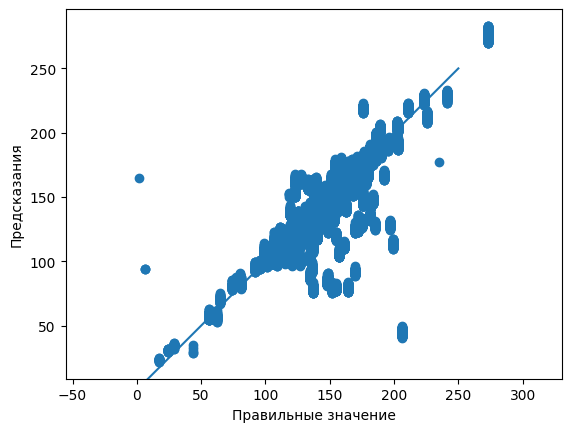

656/656 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 17.3239 - mae: 17.3239 - val_loss: 27.6166 - val_mae: 27.6166
Epoch 2/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 8.166 очков это 5.385% от общей выборки в 52450 игры


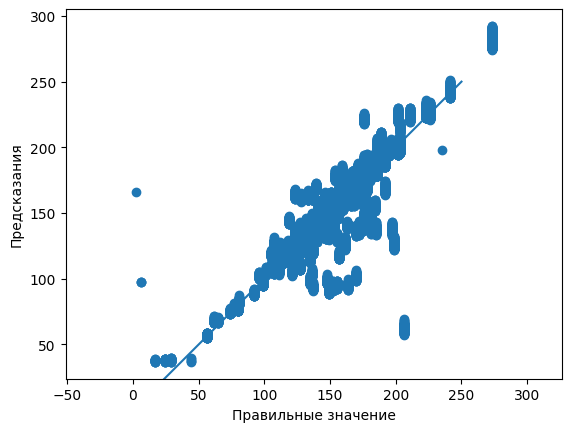

656/656 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 8.5482 - mae: 8.5482 - val_loss: 23.4922 - val_mae: 23.4922
Epoch 3/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 8.389 очков это 5.533% от общей выборки в 52450 игры


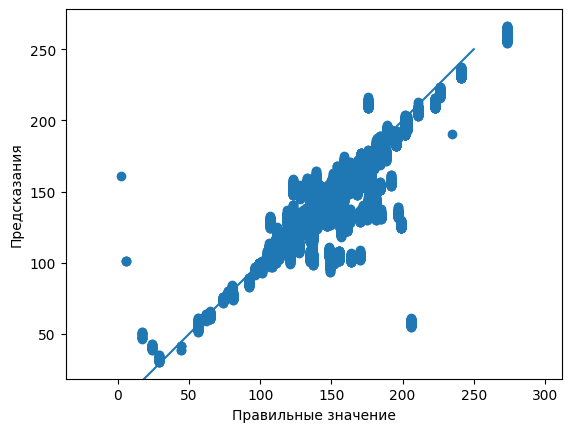

656/656 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 7.9196 - mae: 7.9196 - val_loss: 22.4023 - val_mae: 22.4023
Epoch 4/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 9.592 очков это 6.326% от общей выборки в 52450 игры


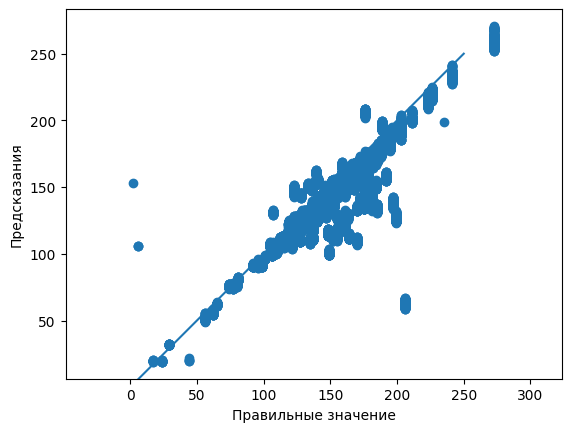

656/656 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 7.4296 - mae: 7.4296 - val_loss: 20.8139 - val_mae: 20.8139
Epoch 5/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 7.792 очков это 5.139% от общей выборки в 52450 игры


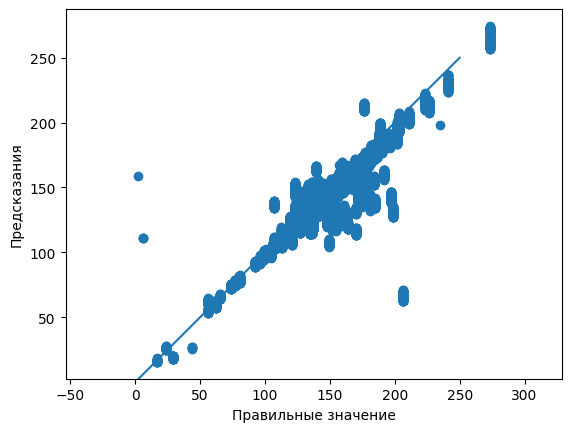

656/656 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 7.1151 - mae: 7.1151 - val_loss: 18.9610 - val_mae: 18.9610
Epoch 6/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 5.375 очков это 3.545% от общей выборки в 52450 игры


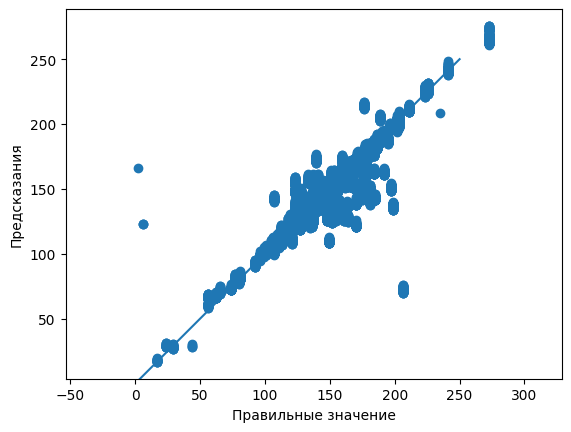

656/656 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 7.0164 - mae: 7.0164 - val_loss: 17.3450 - val_mae: 17.3450
Epoch 7/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 5.072 очков это 3.345% от общей выборки в 52450 игры


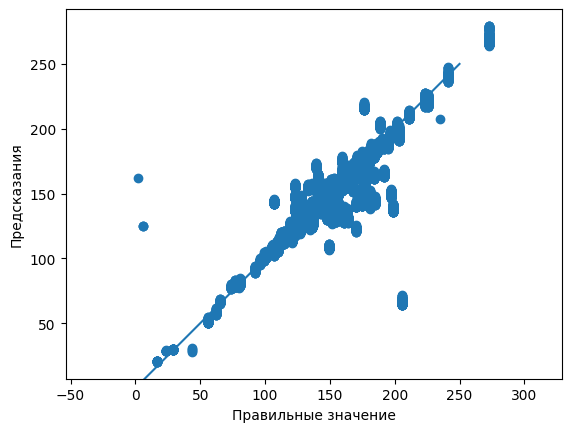

656/656 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - loss: 6.8581 - mae: 6.8581 - val_loss: 16.9943 - val_mae: 16.9943
Epoch 8/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 6.798 очков это 4.484% от общей выборки в 52450 игры


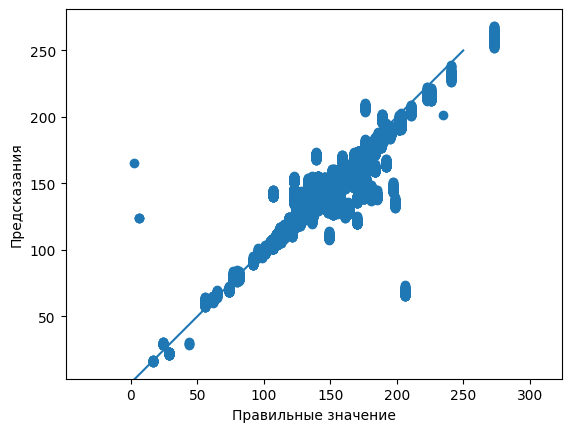

656/656 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 6.7186 - mae: 6.7186 - val_loss: 17.2537 - val_mae: 17.2537
Epoch 9/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 7.520 очков это 4.960% от общей выборки в 52450 игры


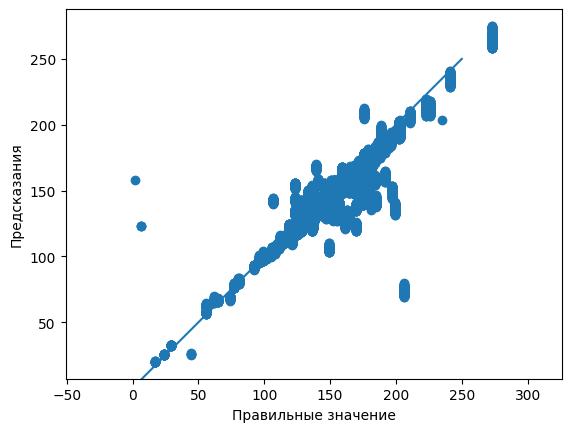

656/656 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 6.6001 - mae: 6.6001 - val_loss: 17.4002 - val_mae: 17.4002
Epoch 10/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 5.337 очков это 3.520% от общей выборки в 52450 игры


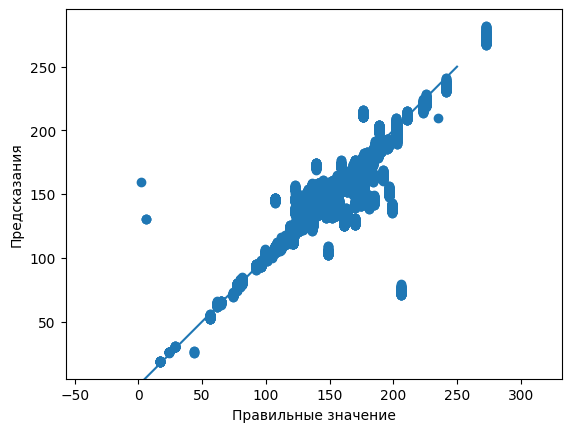

656/656 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 6.5557 - mae: 6.5557 - val_loss: 16.4585 - val_mae: 16.4585
Epoch 11/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


Среднаяя абслолютная ошибка 5.793 очков это 3.820% от общей выборки в 52450 игры


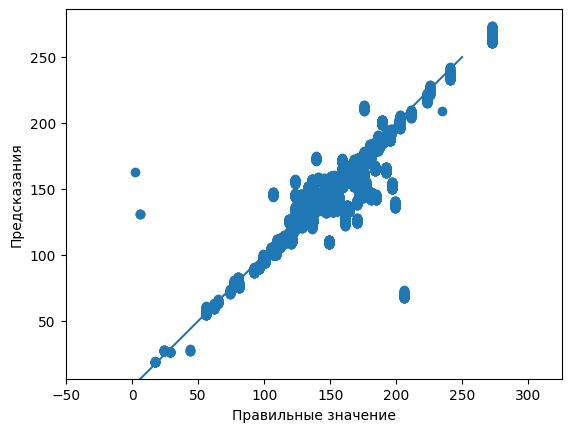

656/656 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 6.4999 - mae: 6.4999 - val_loss: 16.5917 - val_mae: 16.5917
Epoch 12/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 5.092 очков это 3.358% от общей выборки в 52450 игры


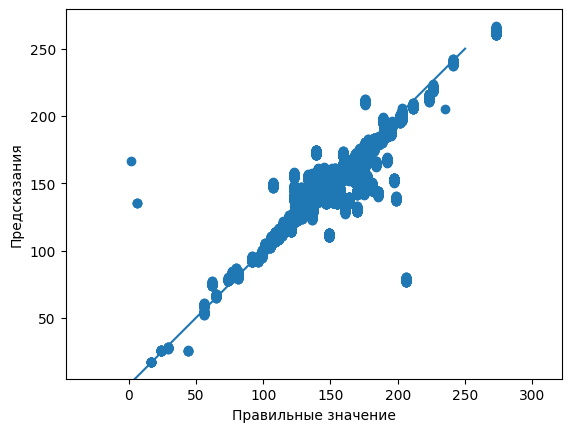

656/656 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 6.4147 - mae: 6.4147 - val_loss: 15.9431 - val_mae: 15.9431
Epoch 13/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 5.286 очков это 3.486% от общей выборки в 52450 игры


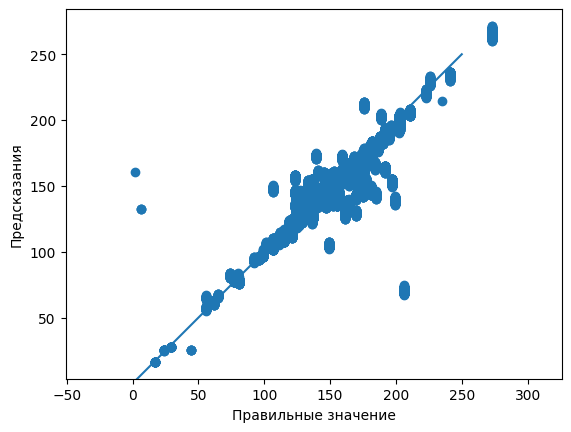

656/656 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 6.3510 - mae: 6.3510 - val_loss: 16.1597 - val_mae: 16.1597
Epoch 14/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 5.520 очков это 3.641% от общей выборки в 52450 игры


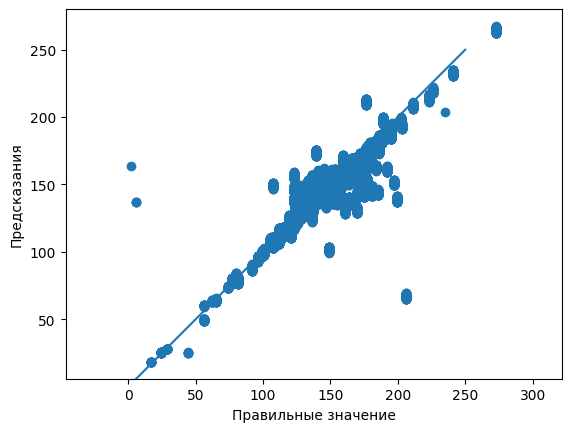

656/656 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 6.0968 - mae: 6.0968 - val_loss: 16.6190 - val_mae: 16.6190
Epoch 15/30
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 8.111 очков это 5.349% от общей выборки в 52450 игры


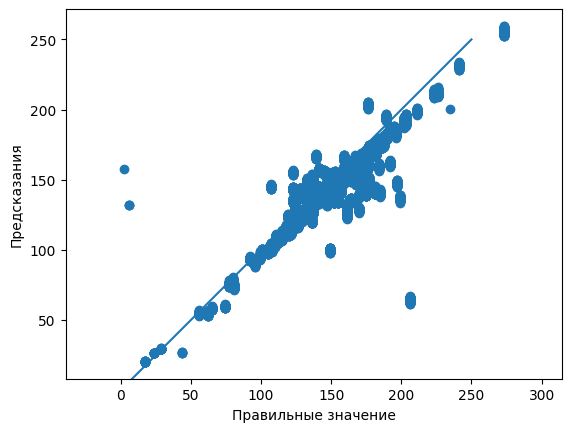

656/656 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 5.8331 - mae: 5.8331 - val_loss: 16.9575 - val_mae: 16.9575


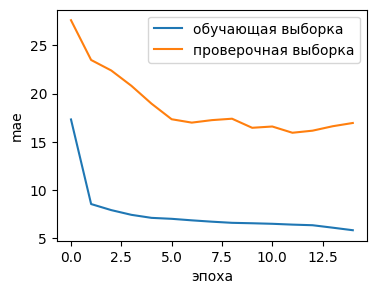

1640/1640 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Среднаяя абслолютная ошибка 5.092 очков это 3.358% от общей выборки в 52450 игры


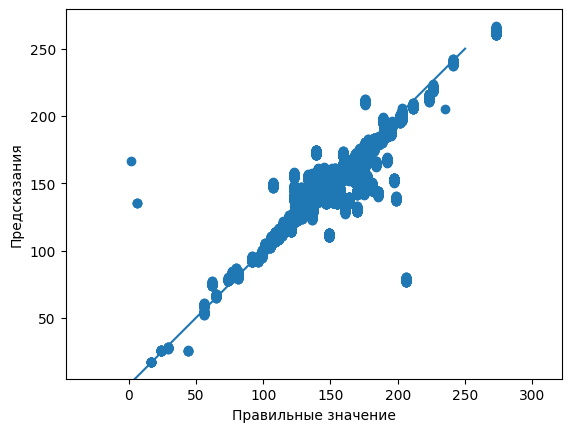

In [ ]:
# ваше решение
# импортирование библиотек
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, concatenate
from tensorflow.keras.callbacks import LambdaCallback
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

# масштабирование числовых данных
scaler_x = StandardScaler()
xTrain_scaled = scaler_x.fit_transform(xTrain)

# создание входа числовых данных
input_num = Input(shape=(xTrain_scaled.shape[1],))

# создание ветки числовых данных
x_num = Dense(64, activation='relu')(input_num)
x_num = Dense(32, activation='relu')(x_num)

# создание входа текстовых данных
input_text = Input(shape=(xBOW_text.shape[1],))

# создание ветки текстовых данных
x_text = Dense(256, activation='relu')(input_text)
x_text = Dropout(0.2)(x_text)
x_text = Dense(128, activation='relu')(x_text)

# объединение данных
merged = concatenate([x_num, x_text])

# создание общей части сети
x = Dense(128, activation='relu')(merged)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)

# создание выхода
output = Dense(1, activation='linear')(x)

# создание модели
model_final_scaled = Model(inputs=[input_num, input_text], outputs=output)

# компиляция модели
model_final_scaled.compile(optimizer='adam', loss='mae', metrics=['mae'])

# создание callback
callback = LambdaCallback(on_epoch_end=lambda epoch, logs: on_epoch_end_custom(epoch))

stop = EarlyStopping(monitor='val_mae', patience=3, restore_best_weights=True)

history = model_final_scaled.fit([xTrain_scaled, xBOW_text], yTrain, epochs=30, batch_size=64, callbacks=[callback, stop], validation_split=0.2, verbose=1)

# построение графика
plt.figure(figsize=(4, 3))
plt.plot(history.history['mae'], label='обучающая выборка')
plt.plot(history.history['val_mae'], label='проверочная выборка')
plt.xlabel('эпоха')
plt.ylabel('mae')
plt.legend()
plt.show()

# проверка результата
check_MAE_predictl_DubbleInput(model_final_scaled, xTrain_scaled, xBOW_text, yTrain, plot=True)

Для решения задачи требуются знания по теме `Callbacks`, пожалуйста, изучите раздел:

---
Дополнителная информация: ([База знаний УИИ – **«Callbacks»**](https://colab.research.google.com/drive/1COE1R3kFhRlxPm9X6hQMvjKoiFFt83xW?usp=sharing))

---